# GGMP — 1D Distributional Regression Demo

This notebook demonstrates the **Gaussian GP for Gaussian Mixture data (GGMP)** model on a synthetic 1D example.

Each "observation" at an input location $x$ is not a scalar but an entire probability distribution.  The true generating process is a two-component Gaussian mixture whose component means vary smoothly with $x$:

$$p(y \mid x) = w_1 \, \mathcal{N}\!\left(y \mid \mu_1(x),\, \sigma_1^2\right) + w_2 \, \mathcal{N}\!\left(y \mid \mu_2(x),\, \sigma_2^2\right)$$

with $\mu_1(x) = -1.0 + 0.6\sin(2\pi x)$ (always negative) and $\mu_2(x) = 1.5 + 0.5\cos(\pi x)$ (always positive).  The two modes never cross, which keeps component identification trivial via sort-by-mean.

The GGMP workflow has three phases (per the GGMP paper):

1. **Local GMM fitting** — fit a K-component GMM at each station to extract per-component means and variances; align components across stations.
2. **Component-wise GP training** — one GP per component, trained on the aligned component means with the per-component variances as the noise.
3. **Mixture weight optimization** — EM on the density objective.

Stages 2 and 3 are both performed by `GGMP.train()`.  Stage 1 we do explicitly below so that `initLikelihoods()` receives meaningful per-component means and variances.  Skipping Stage 1 and relying on the default initialization causes the GPs to collapse to constants, because the default uses the *bimodal* variance (which is huge) as the GP noise.

CAUTION: Beta release. The current implementation of GGMP is a proof-of-concept and may contain unknown bugs.  
It is recommended to test on synthetic data before applying to real datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from fvgp import ggmp as ggmp_module
from fvgp.ggmp import GGMP, hyperparameters, fit_gmm_fixed_weights

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
BLUE, ORANGE, GREEN, RED = "#3A86FF", "#FF6B35", "#2EC4B6", "#E63946"

## 1. Synthetic data

We place **14 training stations** in $[0.05, 0.95]$.  At each station we draw 500 samples from the true two-component GMM and store both the samples (for Stage 1 GMM fitting) and a smoothed density curve (the `y_data` GGMP expects).

In [2]:
# True generating process.  Non-crossing component means keep sort-by-mean
# alignment correct across stations.
K = 2
w_true = np.array([0.45, 0.55])
sigma1, sigma2 = 0.30, 0.25

def mu1(x):
    """Lower mode: always in [-1.6, -0.4]."""
    return np.squeeze(-1.0 + 0.6 * np.sin(2 * np.pi * np.asarray(x, dtype=float).ravel()))

def mu2(x):
    """Upper mode: always in [1.0, 2.0]."""
    return np.squeeze( 1.5 + 0.5 * np.cos(np.pi     * np.asarray(x, dtype=float).ravel()))

N_train = 14
x_train = np.linspace(0.05, 0.95, N_train).reshape(-1, 1)
domain  = np.linspace(-3.5, 3.5, 300)

n_samples_per_station = 500
y_data = []
station_samples = []
for xi in x_train[:, 0]:
    m1, m2 = float(mu1(xi)), float(mu2(xi))

    # Sample from the true GMM at this station
    comp = rng.choice(2, size=n_samples_per_station, p=w_true)
    samp = np.where(comp == 0,
                    rng.normal(m1, sigma1, n_samples_per_station),
                    rng.normal(m2, sigma2, n_samples_per_station))
    station_samples.append(samp)

    # Smooth density on a shared grid (this is what y_data must contain)
    dens = (w_true[0] * norm.pdf(domain, m1, sigma1) +
            w_true[1] * norm.pdf(domain, m2, sigma2))
    y_data.append((domain.copy(), dens))

N_pred = 120
x_pred = np.linspace(0.0, 1.0, N_pred).reshape(-1, 1)

print(f"Generated {N_train} stations × {n_samples_per_station} samples each.")

Generated 14 stations × 500 samples each.


### Plot: observed distributional data

Each ridge is one station's smoothed PDF — clearly bimodal because the two modes are always well-separated.

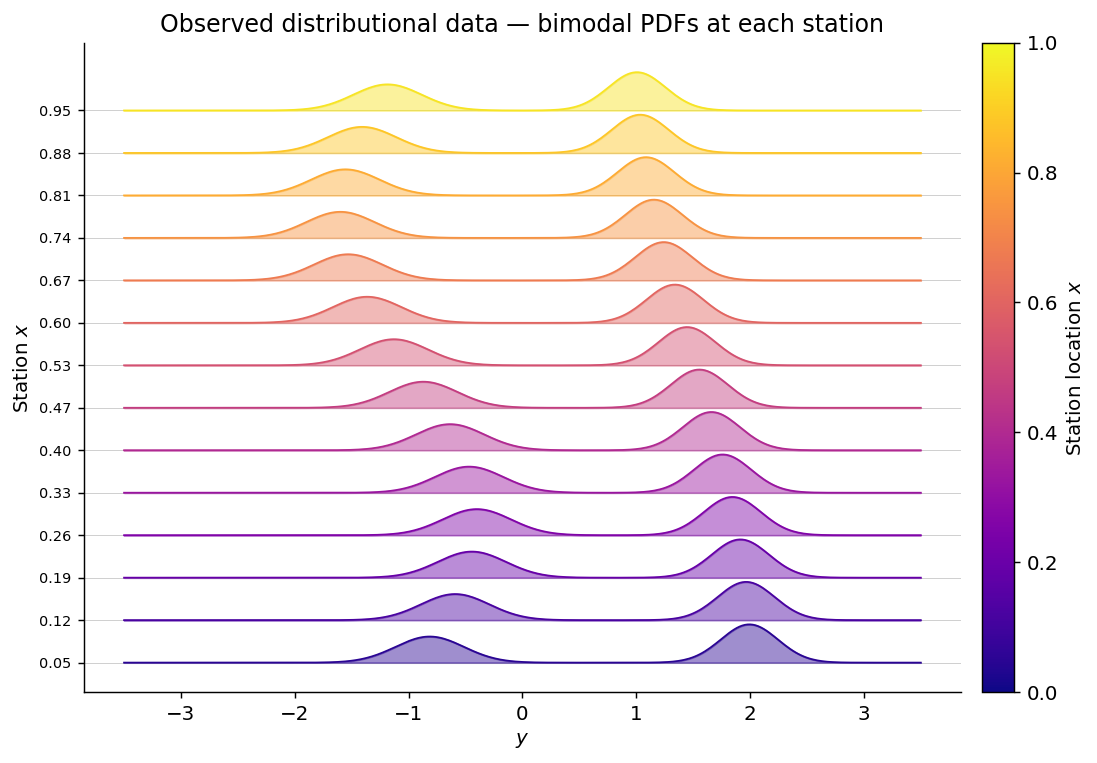

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.plasma
offset_scale = 1.5

for i, (xi, (dom, dens)) in enumerate(zip(x_train[:, 0], y_data)):
    offset = i * offset_scale
    norm_dens = dens / (dens.max() + 1e-12) * offset_scale * 0.9
    color = cmap(xi)
    ax.fill_between(dom, offset, offset + norm_dens, alpha=0.45, color=color)
    ax.plot(dom, offset + norm_dens, lw=1.0, color=color)
    ax.axhline(offset, color="#cccccc", lw=0.5, zorder=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02)
cb.set_label("Station location $x$")

ax.set_xlabel("$y$")
ax.set_yticks(np.arange(N_train) * offset_scale)
ax.set_yticklabels([f"{xi:.2f}" for xi in x_train[:, 0]], fontsize=8)
ax.set_ylabel("Station $x$")
ax.set_title("Observed distributional data — bimodal PDFs at each station")
plt.tight_layout(); plt.show()

## 2. Phase 1 — local GMM fitting

For each station we fit a $K=2$ GMM to its samples using `fit_gmm_fixed_weights` (a 1D EM fitter that returns components sorted by mean).  Because $\mu_1(x) < \mu_2(x)$ at every $x$, sorting trivially aligns components — no Hungarian step needed.

The fitted **per-station, per-component variances** become the GP noise.  This is the key difference from the default initialization (which would use the much larger bimodal variance).

Phase-1 GMM fit quality:
  Component 1: MAE(mean)=0.017  MAE(var)=0.0066
  Component 2: MAE(mean)=0.011  MAE(var)=0.0042


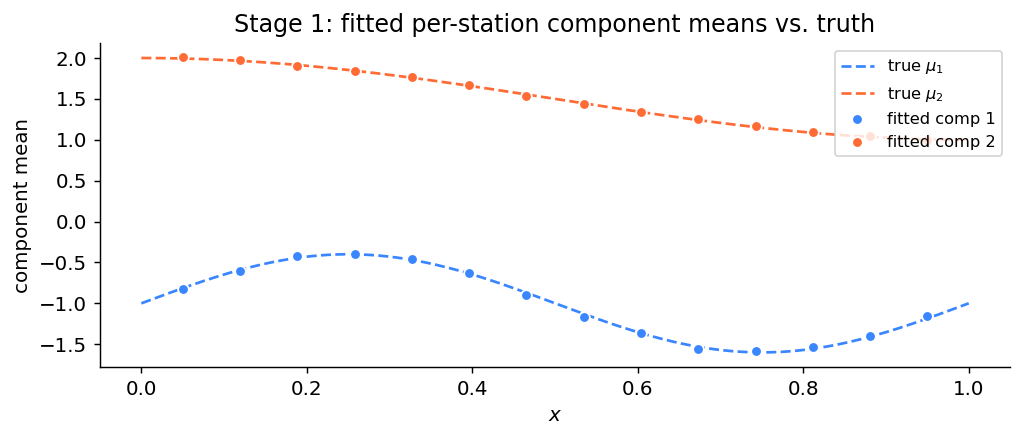

In [4]:
fitted_means = np.zeros((K, N_train))
fitted_vars  = np.zeros((K, N_train))

for n, samples in enumerate(station_samples):
    means_n, vars_n = fit_gmm_fixed_weights(samples, K, w_true, max_iter=80)
    fitted_means[:, n] = means_n   # already sorted by mean
    fitted_vars[:, n]  = vars_n

print("Phase-1 GMM fit quality:")
for k in range(K):
    true_mu  = mu1(x_train) if k == 0 else mu2(x_train)
    true_var = sigma1**2  if k == 0 else sigma2**2
    mae_mu  = np.mean(np.abs(fitted_means[k] - true_mu))
    mae_var = np.mean(np.abs(fitted_vars[k] - true_var))
    print(f"  Component {k+1}: MAE(mean)={mae_mu:.3f}  MAE(var)={mae_var:.4f}")

# Visual check of Stage 1
fig, ax = plt.subplots(figsize=(8, 3.5))
xx = np.linspace(0, 1, 200)
ax.plot(xx, mu1(xx), "--", color=BLUE,   lw=1.5, label=r"true $\mu_1$")
ax.plot(xx, mu2(xx), "--", color=ORANGE, lw=1.5, label=r"true $\mu_2$")
ax.scatter(x_train[:, 0], fitted_means[0], color=BLUE,   s=35, edgecolors="white",
           label="fitted comp 1", zorder=5)
ax.scatter(x_train[:, 0], fitted_means[1], color=ORANGE, s=35, edgecolors="white",
           label="fitted comp 2", zorder=5)
ax.set_xlabel("$x$"); ax.set_ylabel("component mean")
ax.set_title("Stage 1: fitted per-station component means vs. truth")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

## 3. Build the GGMP model

Each component GP uses a Matérn kernel with three hyperparameters: signal variance, length scale, and a trainable constant prior mean.  We pass the Stage-1 fitted means and standard deviations into `initLikelihoods` so each component GP sees the right signal and a realistic (small) noise level.

In [5]:
# 3 params per GP: [signal_var, length_scale, prior_mean]
hps_init   = [np.array([0.3, 0.3, 0.0])] * K
hps_bounds = [np.array([[0.01, 5.0],
                         [0.05, 3.0],
                         [-5.0, 5.0]])] * K

weights_init   = np.ones(K) / K
weights_bounds = np.array([[0.01, 1.0]] * K)

hps_obj = hyperparameters(weights_init, weights_bounds, hps_init, hps_bounds)

g = GGMP(x_train, y_data, hps_obj=hps_obj, likelihood_terms=K)

# Seed likelihoods with the Stage-1 fit
g.initLikelihoods(
    init_mean=[fitted_means[k] for k in range(K)],
    init_std=[np.sqrt(fitted_vars[k]) for k in range(K)],
    weights=weights_init,
)
g.initGPs()

print(f"Initialized {K} component GPs over {N_train} stations.")
for k in range(K):
    print(f"  Component {k+1}: hps = {g.gps[k].hyperparameters}")

[initGPs] Synced hps_obj: mean values = [-0.9987636991344491, 1.504783949356897]
Initialized 2 component GPs over 14 stations.
  Component 1: hps = [ 0.3        0.3       -0.9987637]
  Component 2: hps = [0.3        0.3        1.50478395]


## 4. Train

`train()` runs Phase 2 (per-component GP hyperparameter optimization) followed by Phase 3 (EM on mixture weights with the density objective).

In [6]:
synced_hps = g.train(
    method="local",
    max_iter=300,
    train_weights=True,
    weight_method="density",
    weight_max_iter=300,
)

learned_weights = np.array([g.likelihoods[k].weight for k in range(K)])
print("\nTrained hyperparameters:")
for k, hps in enumerate(synced_hps):
    print(f"  Component {k+1}: signal_var={hps[0]:.3f}  length_scale={hps[1]:.3f}  prior_mean={hps[2]:.3f}")
print(f"\nLearned weights: {learned_weights}  (true: {w_true})")


Trained hyperparameters:
  Component 1: signal_var=0.154  length_scale=0.285  prior_mean=-0.997
  Component 2: signal_var=0.217  length_scale=0.733  prior_mean=1.502

Learned weights: [0.449997 0.550003]  (true: [0.45 0.55])


## 5. Posterior predictions

We evaluate the posterior on a fine grid over $[0, 1]$:

- the **mixture mean** $\mu(x^*) = \sum_k w_k\, \mu_k(x^*)$
- the **mixture variance** via the law of total variance
- the **full predictive density** $p(y^* \mid x^*) = \sum_k w_k\, \mathcal{N}(y^* \mid \mu_k(x^*),\, \nu_k(x^*) + \bar{s}_k^2)$

In [7]:
mix_mean = g.posterior_mean(x_pred)
mix_var  = g.posterior_variance(x_pred)
mix_std  = np.sqrt(np.maximum(mix_var, 0))

comp_means = np.stack(
    [g.gps[k].posterior_mean(x_pred)["m(x)"] for k in range(K)], axis=0
)
comp_vars = np.stack(
    [g.gps[k].posterior_covariance(x_pred, variance_only=True)["v(x)"] for k in range(K)], axis=0
)
mean_noise = np.array([np.mean(g.likelihoods[k].variance) for k in range(K)])
comp_stds  = np.sqrt(np.maximum(comp_vars + mean_noise[:, None], 0))

y_grid = np.linspace(-3.5, 3.5, 400)
w_norm = learned_weights / learned_weights.sum()

pred_density = np.zeros((N_pred, len(y_grid)))
for k in range(K):
    for i in range(N_pred):
        pred_density[i] += w_norm[k] * norm.pdf(
            y_grid, loc=comp_means[k, i], scale=comp_stds[k, i]
        )

print("Prediction complete.")

Prediction complete.


### Plot: component GP posteriors

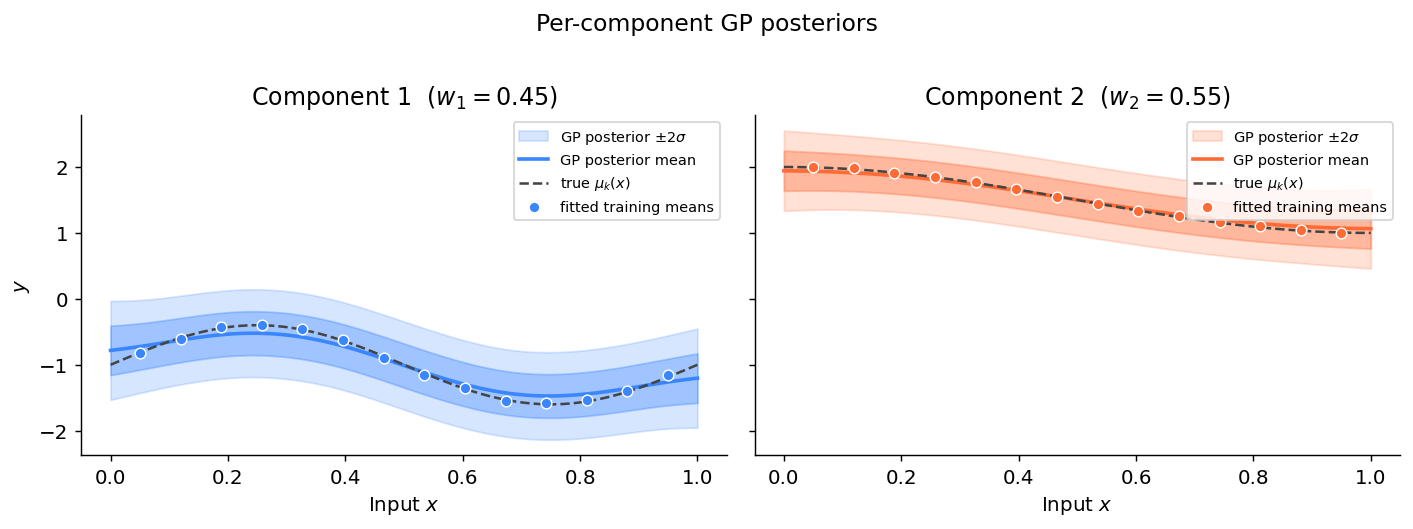

In [8]:
colors_k = [BLUE, ORANGE]
x_plot   = x_pred[:, 0]
x_train_plot = x_train[:, 0]
true_funcs = [mu1, mu2]

fig, axes = plt.subplots(1, K, figsize=(11, 4), sharey=True)

for k, ax in enumerate(axes):
    mu_k  = comp_means[k]
    std_k = comp_stds[k]
    c = colors_k[k]

    ax.fill_between(x_plot, mu_k - 2*std_k, mu_k + 2*std_k,
                    alpha=0.20, color=c, label=r"GP posterior $\pm 2\sigma$")
    ax.fill_between(x_plot, mu_k - std_k, mu_k + std_k,
                    alpha=0.35, color=c)
    ax.plot(x_plot, mu_k, color=c, lw=2, label="GP posterior mean")

    true_mu = true_funcs[k](x_pred)
    ax.plot(x_plot, true_mu, "--", color="#444444", lw=1.4, label=r"true $\mu_k(x)$")

    ax.scatter(x_train_plot, fitted_means[k], s=35, color=c,
               edgecolors="white", linewidths=0.8, zorder=5,
               label="fitted training means")

    ax.set_xlabel("Input $x$")
    if k == 0: ax.set_ylabel("$y$")
    ax.set_title(f"Component {k+1}  ($w_{k+1} = {w_norm[k]:.2f}$)")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Per-component GP posteriors", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### Plot: full predictive density

The heat map shows $p(y^* \mid x^*)$ across the prediction grid.  The two bands correspond to the two mixture components.

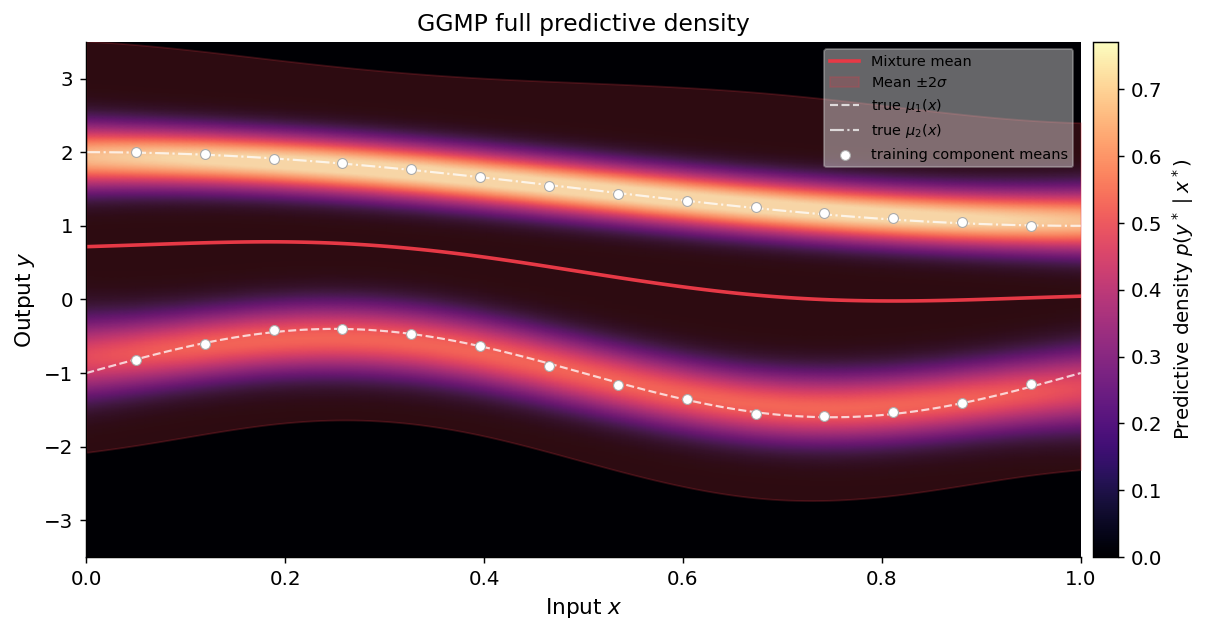

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

pcm = ax.pcolormesh(
    x_pred[:, 0], y_grid, pred_density.T,
    cmap="magma", shading="gouraud",
    vmin=0, vmax=pred_density.max() * 0.95,
)
cb = fig.colorbar(pcm, ax=ax, pad=0.01)
cb.set_label("Predictive density $p(y^* \\mid x^*)$")

ax.plot(x_plot, mix_mean, color=RED, lw=2.0, label="Mixture mean")
ax.fill_between(x_plot, mix_mean - 2*mix_std, mix_mean + 2*mix_std,
                color=RED, alpha=0.20, label=r"Mean $\pm 2\sigma$")

ax.plot(x_plot, mu1(x_pred), "--", color="white", lw=1.2, alpha=0.75, label=r"true $\mu_1(x)$")
ax.plot(x_plot, mu2(x_pred), "-.", color="white", lw=1.2, alpha=0.75, label=r"true $\mu_2(x)$")

ax.scatter(x_train[:, 0], fitted_means[0], s=30, color="white",
           edgecolors="#aaaaaa", linewidths=0.6, zorder=5)
ax.scatter(x_train[:, 0], fitted_means[1], s=30, color="white",
           edgecolors="#aaaaaa", linewidths=0.6, zorder=5,
           label="training component means")

ax.set_xlabel("Input $x$", fontsize=12)
ax.set_ylabel("Output $y$", fontsize=12)
ax.set_title("GGMP full predictive density", fontsize=13)
ax.legend(fontsize=8, loc="upper right", framealpha=0.4)
ax.set_xlim(x_pred[0, 0], x_pred[-1, 0])
ax.set_ylim(y_grid[0], y_grid[-1])
plt.tight_layout(); plt.show()

### Plot: training data vs posterior side by side

Solid green = observed density at the station; dashed red = GGMP predictive density at the same location.

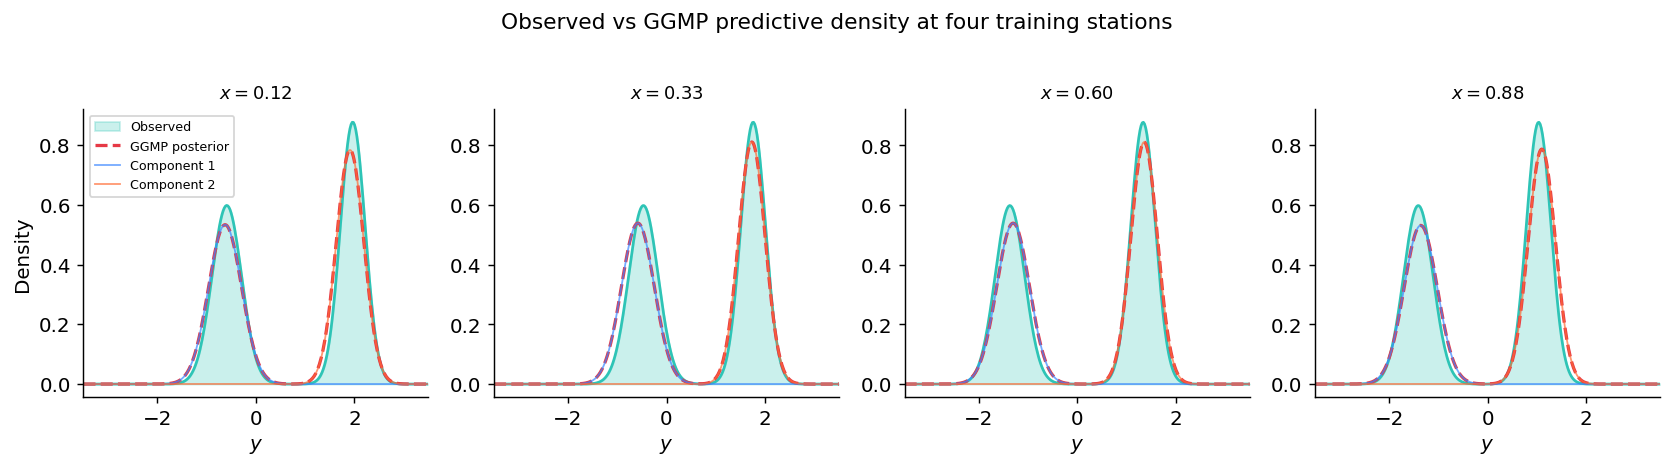

In [10]:
station_ids = [1, 4, 8, 12]
x_sel = x_train[station_ids]

comp_means_sel = np.stack(
    [g.gps[k].posterior_mean(x_sel)["m(x)"] for k in range(K)], axis=0
)
comp_vars_sel = np.stack(
    [g.gps[k].posterior_covariance(x_sel, variance_only=True)["v(x)"] for k in range(K)], axis=0
)
comp_stds_sel = np.sqrt(np.maximum(comp_vars_sel + mean_noise[:, None], 0))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), sharey=False)

for col, (sid, ax) in enumerate(zip(station_ids, axes)):
    xi = float(x_train[sid, 0])
    dom, dens = y_data[sid]
    _, p_obs, _ = ggmp_module._normalize_pdf(dom, dens)

    ax.fill_between(dom, p_obs, alpha=0.25, color=GREEN, label="Observed")
    ax.plot(dom, p_obs, color=GREEN, lw=1.5)

    pred = np.zeros(len(y_grid))
    for k in range(K):
        pred += w_norm[k] * norm.pdf(
            y_grid,
            loc=float(comp_means_sel[k, col]),
            scale=float(comp_stds_sel[k, col]),
        )
    ax.plot(y_grid, pred, "--", color=RED, lw=1.8, label="GGMP posterior")

    for k, c in enumerate(colors_k):
        comp_curve = norm.pdf(
            y_grid,
            loc=float(comp_means_sel[k, col]),
            scale=float(comp_stds_sel[k, col]),
        )
        ax.plot(y_grid, w_norm[k] * comp_curve, color=c, lw=1.0, alpha=0.7,
                label=f"Component {k+1}" if col == 0 else None)

    ax.set_title(f"$x = {xi:.2f}$", fontsize=10)
    ax.set_xlabel("$y$")
    if col == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)
    ax.set_xlim(dom[0], dom[-1])

fig.suptitle("Observed vs GGMP predictive density at four training stations",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 6. Prediction at unseen locations

Three test locations not in the training set — pure generalization.

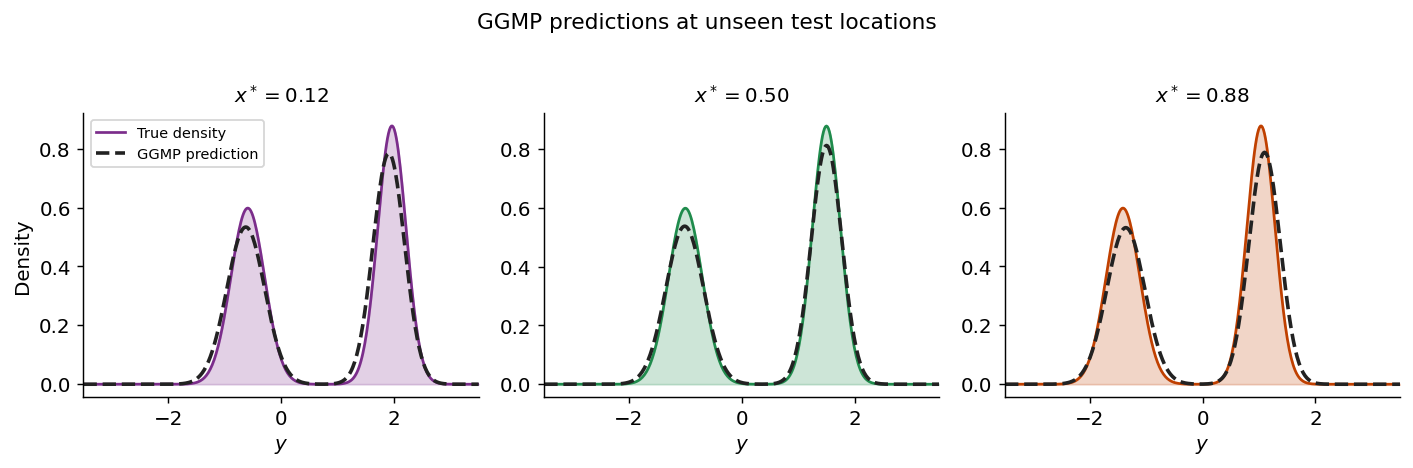

In [11]:
x_test = np.array([[0.12], [0.50], [0.88]])
labels = [f"$x^* = {xi:.2f}$" for xi in x_test[:, 0]]

comp_means_test = np.stack(
    [g.gps[k].posterior_mean(x_test)["m(x)"] for k in range(K)], axis=0
)
comp_vars_test = np.stack(
    [g.gps[k].posterior_covariance(x_test, variance_only=True)["v(x)"] for k in range(K)], axis=0
)
comp_stds_test = np.sqrt(np.maximum(comp_vars_test + mean_noise[:, None], 0))

def true_density(xi, y):
    return (w_true[0] * norm.pdf(y, float(mu1(xi)), sigma1) +
            w_true[1] * norm.pdf(y, float(mu2(xi)), sigma2))

colors_test = ["#7B2D8B", "#1F8B4C", "#C04000"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

for col, (xi, ax, lbl, c) in enumerate(
        zip(x_test[:, 0], axes, labels, colors_test)):

    true_dens = true_density(xi, y_grid)
    true_dens /= np.trapezoid(true_dens, y_grid) + 1e-300
    ax.fill_between(y_grid, true_dens, alpha=0.22, color=c)
    ax.plot(y_grid, true_dens, color=c, lw=1.5, label="True density")

    pred = np.zeros(len(y_grid))
    for k in range(K):
        pred += w_norm[k] * norm.pdf(
            y_grid,
            loc=float(comp_means_test[k, col]),
            scale=float(comp_stds_test[k, col]),
        )
    ax.plot(y_grid, pred, "--", color="#222222", lw=2.0, label="GGMP prediction")

    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("$y$")
    if col == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
    ax.set_xlim(y_grid[0], y_grid[-1])

fig.suptitle("GGMP predictions at unseen test locations", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Summary

| Step | Code |
|---|---|
| **Stage 1** — fit local GMMs | `fit_gmm_fixed_weights(samples_n, K, w_init)` for each station |
| Build hyperparameter container | `hyperparameters(weights, w_bounds, hps, hps_bounds)` |
| Construct model | `GGMP(x_data, y_data, hps_obj=hps_obj, likelihood_terms=K)` |
| Seed likelihoods from Stage 1 | `g.initLikelihoods(init_mean=..., init_std=..., weights=...)` |
| Build component GPs | `g.initGPs()` |
| **Stages 2 & 3** — GP hps + weights | `g.train(method="local", weight_method="density")` |
| Mixture mean | `g.posterior_mean(x_pred)` |
| Mixture variance | `g.posterior_variance(x_pred)` |
| Full predictive density | `∑_k w_k N(y \| μ_k(x*), ν_k(x*) + s̄²_k)` per prediction point |

Skipping Stage 1 and relying on `initLikelihoods()`'s default initialization causes the GPs to collapse to constants, because the default uses the bimodal variance (large) as the GP noise.  Stage 1 produces the per-component variances that give the GP a realistic noise level.